# Training a neural network for XOR using ES(1+1) with 1/5 rule
- 9 weight values to optimize
- Use sigmoid activation function for all neurons
- Not generalized for N hidden layers with M neurons for each hidden Layer
- CJ Chung 2022-

<image src=https://www.robofest.net/DL/XOR_sigmoid.png width=300>

In [37]:
import numpy as np
from math import exp, tanh
from random import random, gauss
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [38]:
def sigmoid(ws):
  return 1.0 / (1.0 + exp(-1.0*ws))

def stairStep(ws):
  if ws > 0:
    return 1.0
  else:
    return 0

def relu(ws):
  return max(0.0, ws)

def tanh(ws):
  return (exp(ws) - exp(-ws)) / (exp(ws) + exp(-ws))

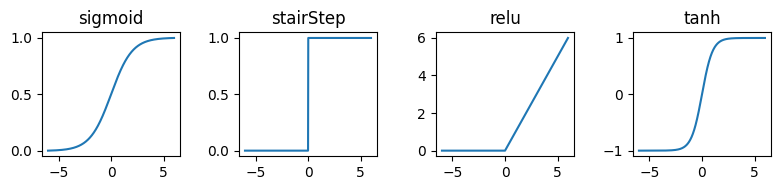

In [39]:
x = np.arange(-6, 6, 0.01) # Grid of 0.01 spacing from -pi to pi
act_funcs = (sigmoid, stairStep, relu, tanh)

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, len(act_funcs), figsize=(8, 2)) # 1 row, 4 columns, smaller figure size

# Plot each activation function in a subplot
for i, act_fuc in enumerate(act_funcs):
  y = [act_fuc(val) for val in x] # List comprehension
  axes[i].plot(x, y)
  axes[i].set_title(act_fuc.__name__) # Set title to function name

plt.tight_layout() # Adjust layout to prevent titles overlapping
plt.show()

In [40]:
# inputs are       a, b, 1 (bias)
input = np.array([[0, 0, 1],
                  [0, 1, 1],
                  [1, 0, 1],
                  [1, 1, 1]], dtype=float)
desired_out = np.array([0, 1, 1, 0], float)
hidden = np.array([0, 0], float) # to store output of each hidden neuron
test_input = np.array([[0.01, 0, 1],
                      [0, 0.95, 1],
                      [1, 0.05, 1],
                      [0.9, 1, 1]], dtype=float)

In [41]:
# feed forward propagation
def ffp(w, input_arr, i, activation_f): #One hidden layer Feed Forward, i = sample pattern index
  m = 0 #index for 9 weights
  for j in range(len(hidden)):
    hidden[j] = 0.0
    for k in range(3):
      hidden[j] += input_arr[i, k] * w[m]
      m = m+1
    hidden[j] = activation_f(hidden[j])

  NN_output = 0.0
  for n in range(len(hidden)):
    NN_output += hidden[n] * w[m]
    m = m+1

  NN_output += w[m] # for bias
  NN_output = activation_f(NN_output)
  return NN_output

def objFunc(x, input_arr, act_fn): # x = weight vec
  errSum = 0.0
  for i in range(4):
    y = ffp(x, input_arr, i, act_fn)
    #y = ffp(x, test_input, i, act_fn) # also works
    errSum += (desired_out[i]-y)**2
  return errSum

In [42]:
def verify(w, act_fn):
  print('\t***** To verify if the w vector above is correct *****')
  for i in range(4):
    y = ffp(w, test_input, i, act_fn)
    # Iterate through input elements for printing
    input_str = ' '.join([f'{x:.2f}' for x in test_input[i]])
    print(f'\t   Test Input: [{input_str}] \tOutput: {y:.1f}')

w1 = np.array([1.7299660387120122, 3.04021437773799, -1.20526745645984, -1.6385111908431627, -2.578129126967211, 3.0036521877830995, 2.505440178023749, 2.5067862885975645, -0.40169355047449445]) # from tanh
w2 = np.array([1.0, 1.0, -0.5, -1.0, -1.0, 1.5, 1.0, 1.0, -1.5]) # works with stairStep
w3 = np.array([15.777498706166504, -13.170463800361835, 6.928145681894125, -9.78751875599886, 15.038835851148951, 8.05298888101147, -11.903670377654652, -14.490754747951865, 19.817246873788978])
verify(w1, tanh)
verify(w2, stairStep)
verify(w3, sigmoid)

	***** To verify if the w vector above is correct *****
	   Test Input: [0.01 0.00 1.00] 	Output: 0.0
	   Test Input: [0.00 0.95 1.00] 	Output: 1.0
	   Test Input: [1.00 0.05 1.00] 	Output: 1.0
	   Test Input: [0.90 1.00 1.00] 	Output: 0.1
	***** To verify if the w vector above is correct *****
	   Test Input: [0.01 0.00 1.00] 	Output: 0.0
	   Test Input: [0.00 0.95 1.00] 	Output: 1.0
	   Test Input: [1.00 0.05 1.00] 	Output: 1.0
	   Test Input: [0.90 1.00 1.00] 	Output: 0.0
	***** To verify if the w vector above is correct *****
	   Test Input: [0.01 0.00 1.00] 	Output: 0.0
	   Test Input: [0.00 0.95 1.00] 	Output: 1.0
	   Test Input: [1.00 0.05 1.00] 	Output: 1.0
	   Test Input: [0.90 1.00 1.00] 	Output: 0.0


In [43]:
def es_1115 (numVar, low, high, maxGen, windowSize, stepSize, act_fn, input, desired_out):
  p = np.zeros(numVar)
  o = np.zeros(numVar)
  sucessCnt = 0

  # Initialize parent solution
  for j in range(numVar):
    p[j] = low + random() * (high-low)
  parentVal = objFunc(p, input, act_fn)

  for gen in range(1, maxGen+1):
    if gen % windowSize == 0: #update step size
      if sucessCnt > windowSize * 0.2:
        stepSize /= 0.82 #increase
      elif sucessCnt < windowSize * 0.2:
        stepSize *= 0.82 #decrease
      sucessCnt = 0

    # Reproduce (create child)
    for j in range(numVar):
      o[j] = p[j] + gauss(0.0, stepSize)
      o[j] = np.clip(o[j], low, high)

    # Evaluate child
    childVal = objFunc(o, input, act_fn)

    # Selection
    if childVal < parentVal:
      #Child becomes a parent for next generation
      for j in range(numVar):
        p[j] = o[j]
      parentVal = childVal
      sucessCnt+=1

    if gen > 1000 and parentVal > 1.0:
      return p, parentVal, gen, False # No hope

    if parentVal < 0.00005:
      return p, parentVal, gen, True # Acceptable solution found

  return p, parentVal, maxGen, False # Reached max generations

In [44]:
def db_graph(w, act_fn):
    q = 100
    xaxis = np.linspace(0, 1, q)
    yaxis = np.linspace(0, 1, q)
    X, Y = np.meshgrid(xaxis, yaxis)


   ##### USED ChatGPT ########
    inputs = np.c_[X.ravel(), Y.ravel(), np.ones(q * q)]

    Z = np.array([ffp(w, inputs, i, act_fn) for i in range(inputs.shape[0])])
    Z = Z.reshape(X.shape)

    cmap = LinearSegmentedColormap.from_list("custom", [
        (0.0, (1.0, 1.0, 0.0)),  # Yellow
        (1.0, (0.0, 0.0, 1.0))   # Blue
    ])
    ############################

    # Plot bd
    fig, ax = plt.subplots()
    pc = ax.pcolormesh(X, Y, Z, cmap=cmap, shading="auto", vmin=0, vmax=1)

    # Add colorbar
    cbar = plt.colorbar(pc, ax=ax)
    cbar.set_label("z_value")

    # Labels and formatting
    ax.set_title('Decision Boundary')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal', adjustable='box')

    plt.show()

Trial = 1,	0.5000088025271819
Trial = 2,	0.500048459011546
Trial = 3,	0.6669850323678529
Trial = 4,	0.5000222161527961
Trial = 5, Acceptable solution found at generation 292
	 w[0]: -14.187722900676786
	 w[1]: -11.359725861592004
	 w[2]: 19.25727575986351
	 w[3]: 8.742287134632148
	 w[4]: 10.108492876046132
	 w[5]: -3.225146966295775
	 w[6]: 11.59678053781112
	 w[7]: 12.378175036525217
	 w[8]: -18.481982892932912
	SSE = 4.9417788740911124e-05
	***** To verify if the w vector above is correct *****
	   Test Input: [0.01 0.00 1.00] 	Output: 0.0
	   Test Input: [0.00 0.95 1.00] 	Output: 1.0
	   Test Input: [1.00 0.05 1.00] 	Output: 1.0
	   Test Input: [0.90 1.00 1.00] 	Output: 0.0


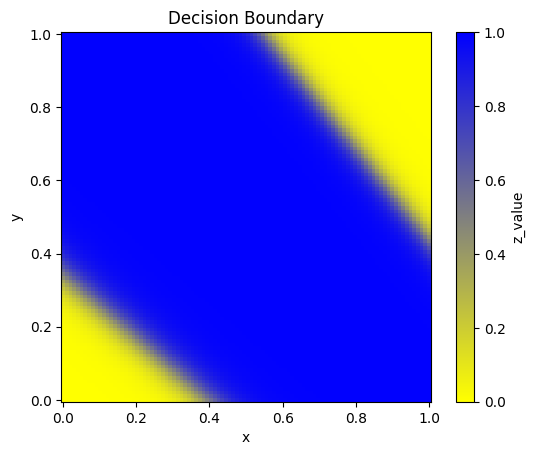

Trial = 6,	0.6667080143421902
Trial = 7,	0.5000272953895034
Trial = 8, Acceptable solution found at generation 757
	 w[0]: -6.2047110865726305
	 w[1]: -7.902348240201236
	 w[2]: 10.72312306800169
	 w[3]: 9.705299459380706
	 w[4]: 9.421851327689517
	 w[5]: -5.248487346552331
	 w[6]: 12.67028495431562
	 w[7]: 11.969900032735453
	 w[8]: -18.27427527510803
	SSE = 4.946158425716068e-05
	***** To verify if the w vector above is correct *****
	   Test Input: [0.01 0.00 1.00] 	Output: 0.0
	   Test Input: [0.00 0.95 1.00] 	Output: 1.0
	   Test Input: [1.00 0.05 1.00] 	Output: 1.0
	   Test Input: [0.90 1.00 1.00] 	Output: 0.0


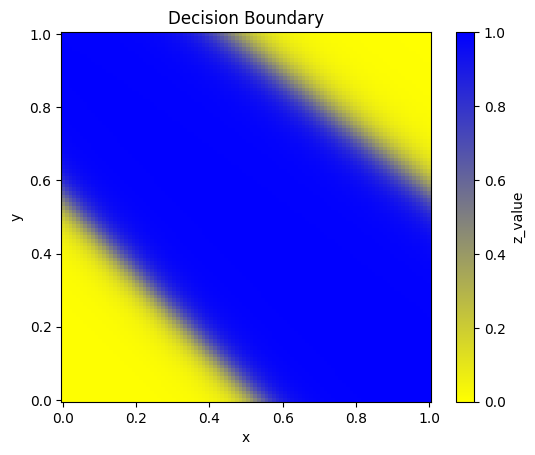

Trial = 9,	0.6667748032167384
Trial = 10,	0.9999998371991053
System Success: 20.0%


In [45]:
####################### M A I N #######################
maxGen = 20000
maxTrial = 10
numVar = 9
act_fn = sigmoid # Note: Keras could not find the optimized NN with sigmoid
low = -20.0 # -5 and 5 did not work
high = 20.0
windowSize = 50 # When 30, 14%; 40-16%, 50-22%
stepSize = 0.82

totGen = 0
foundCnt = 0
for trial in range(1, maxTrial+1):
  best_solution, best_error, generations, success = es_1115 (
      numVar, low, high, maxGen, windowSize, stepSize, act_fn, input, desired_out
  )

  if success:
    print(f'Trial = {trial}, Acceptable solution found at generation {generations}')
    for j in range(numVar):
      print(f"\t w[{j}]: {best_solution[j]}")
    print(f"\tSSE = {best_error}")

    verify(best_solution, act_fn)
    totGen += generations
    foundCnt += 1
    db_graph(best_solution, act_fn)
  elif generations == 1001:
    print(f'Trial = {trial},\t{best_error}\t Terminated, since no hope')
  elif generations == maxGen:
    print(f'Trial = {trial},\t{best_error}')
print(f'System Success: {foundCnt*100/maxTrial:.1f}%')